# Water Allocation Simulation Analysis
This notebook provides tools to analyze the results of the water allocation simulation
across multiple scenarios, focusing on ecological and economic impacts under different
conditions.

## Overview
The simulation tests water allocation policies across various scenarios with different:
- River basins (station configurations)
- Actor compositions (different archetypes from the paper)
- Water scarcity levels
- Forecast error profiles (bias and uncertainty)

The analysis evaluates how these factors affect both ecological integrity and economic benefits.


In this notebook we will:
1. Run the set of evaluation scenarios varying station size, scarcity level,  
   forecast bias and uncertainty.
2. Collect ecological and economic impact metrics for each run.
3. Visualize trade-offs and explore how model parameters influence outcomes.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from types import MethodType
import src.core as wms
import src.plot_analysis as gtp
import src.utils as utils
import src.policies.incentive_policies as eip
import src.policies.quota_policies as eqp
import src.scenarios as sc
import src.fast_scenarios as fsc
import src.utils as utils
import src.plot_multi_analysis as pma
import src.policies.custom_policies as cp
from src.policy_regulation import KwargWrapper, PolicyRegulator

# Set better visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:74: ExperimentalWarning:

NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:75: ExperimentalWarning:

QMCSampler is experimental (supported from v3.0.0). The interface can change in the future.



In [3]:
pol_reg = PolicyRegulator.from_preoptimized('./saved_polices/ecofair_policies')
best_params = pol_reg.study.trials[33].params # best trial
print(best_params)
# TEMP FIX
pol_reg.quota_policy = cp.adaptive_quota
pol_reg.incentives_policy = cp.hard_ecofair_incentives_policy
quota_fn, incentives_fn = pol_reg.get_best_policy_functions(best_params)

{'rate': 1.2391884918766034, 'priority_effect': 0.8609153771995848, 'crisis_rate': 1.1631005662190557, 'max_subvention_weight': -0.5111446274666669, 'max_fine_weight': 4.828160165372797, 'policy_rate': 1.700851999736123, 'crisis_sensitivity': 3.0909313175279762, 'equity_factor': 5.78593358631281, 'subsidy_fine_ratio': 0.5772181268749841, 'alpha': 0.4401524937396013}


## Scenario Definition
Runs simulations across the pre-defined scenarios.
We iterate over:
- **Stations**: Tarn vs. La Vézère  
- **Scarcity levels**: low / medium / high  
- **2 set of actors and variant with heterogenous biaises and uncertainties**  
- **Forecast bias/uncertainty** settings  

Execute the next cell to proceed multo-scenario analysis.


## Multi-Scenario Analysis


Save the results if needed.

In [4]:
%%time
if True:
    results_df = fsc.fast_run_all_scenarios(
        turns=700,
        iterations=10,
        custom_incentive_policy = incentives_fn,
        custom_quota = quota_fn,
        max_workers = 16
    )

Starting simulations across all scenarios...
Generating scenarios configurations...
Scenarios configurations complete!
There are 216 unique configurations
Starting simulations
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty:0.25, Eco Impact: 0.852, Econ Impact: 0.918, Raw Eco Impact: 1670.0, Cooperation %: 49.9%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: -0.5, Uncertainty:0.25, Eco Impact: 0.876, Econ Impact: 0.910, Raw Eco Impact: 1716.0, Cooperation %: 53.3%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.5, Uncertainty:0.5, Eco Impact: 0.850, Econ Impact: 0.917, Raw Eco Impact: 1666.0, Cooperation %: 48.8%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: -0.5, Uncertainty:0.0, Eco Impact: 0.877, Econ Impact: 0.910, Raw Eco Impact: 1718.0, Cooperation %: 52.8%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: -0.25, Uncertainty:0.0, Eco Impact: 0.860, Econ Impact: 0.917, Raw Eco Impact: 1685.0, Cooperation %: 49.1%
Scenario: 0.yml, Station: 1, Scarcity

In [24]:
%%time

if False:
    results_df = sc.run_all_scenarios(
        turns=700,
        iterations=10,
        custom_incentive_policy = incentives_fn,
        custom_quota = quota_fn,
    )


CPU times: user 0 ns, sys: 2 μs, total: 2 μs
Wall time: 3.81 μs


### Ecological vs. economic impact.

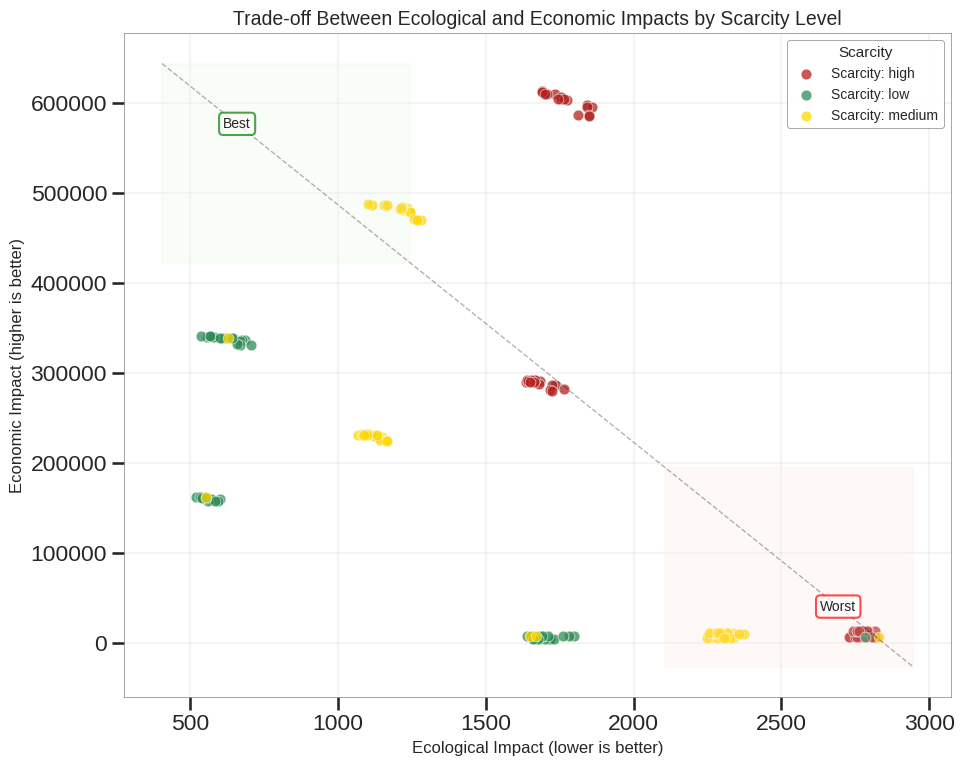

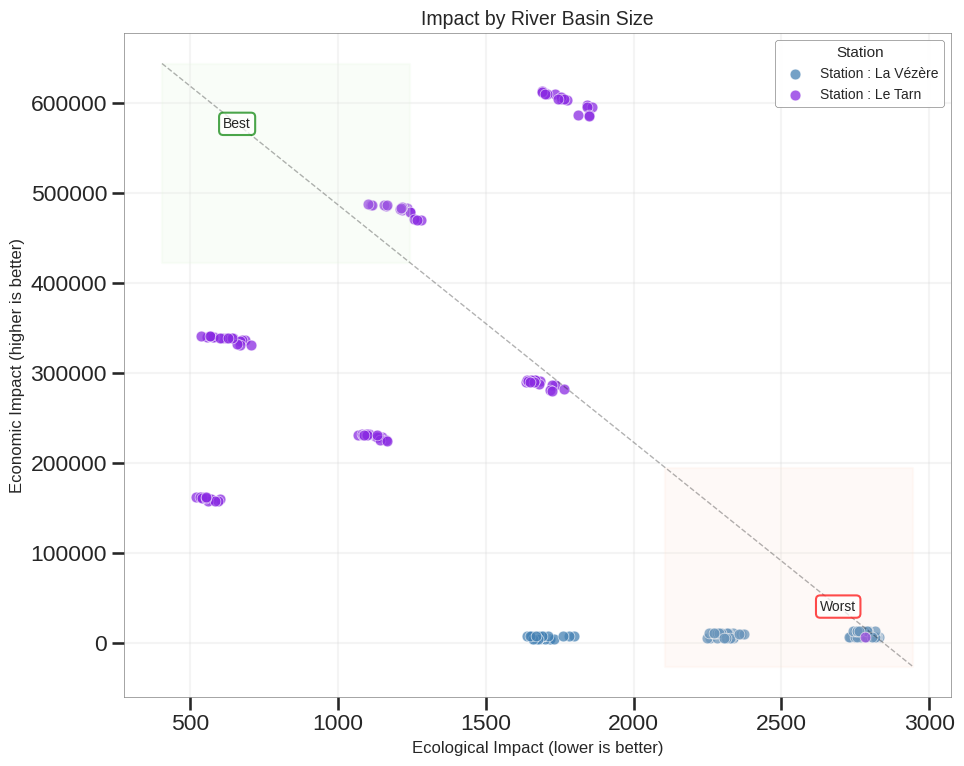

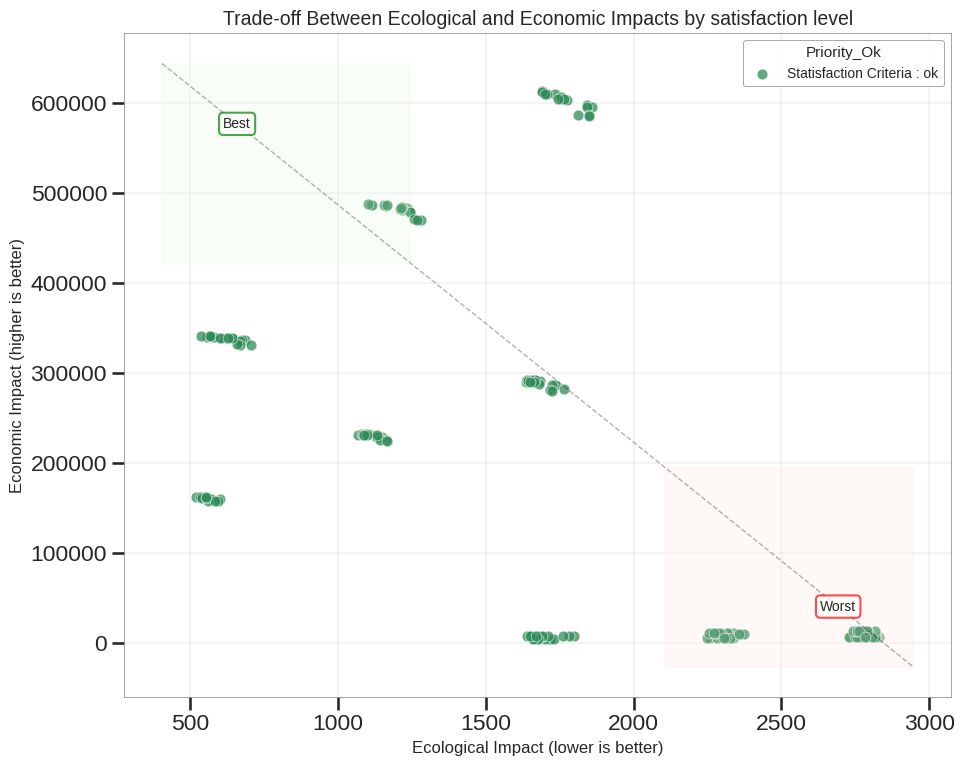

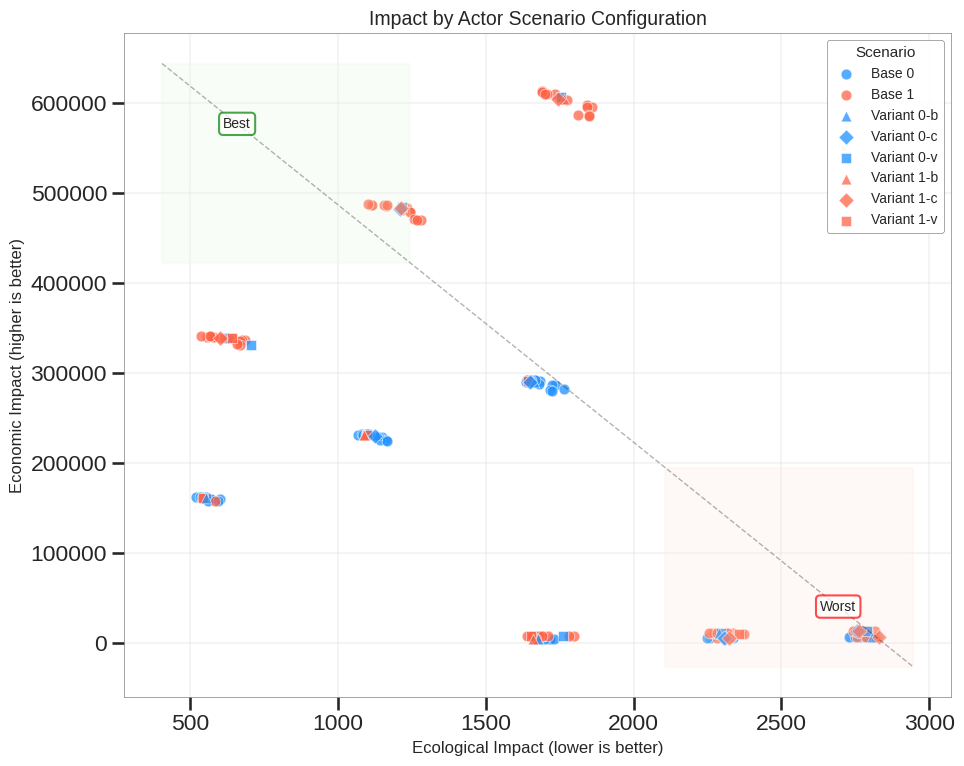

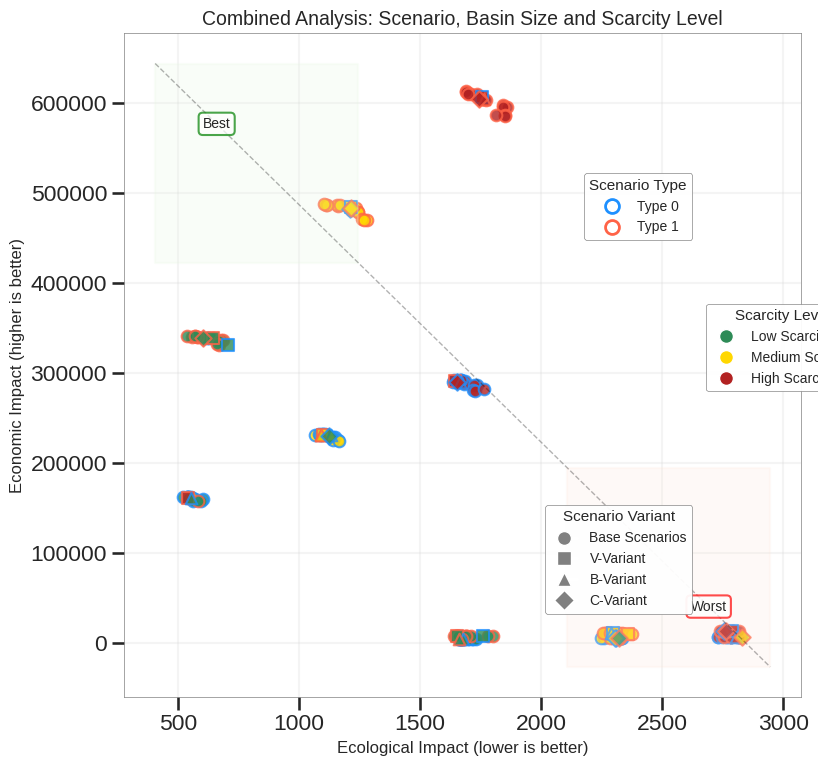

In [5]:
pma.analyze_scenario_impacts(results_df)

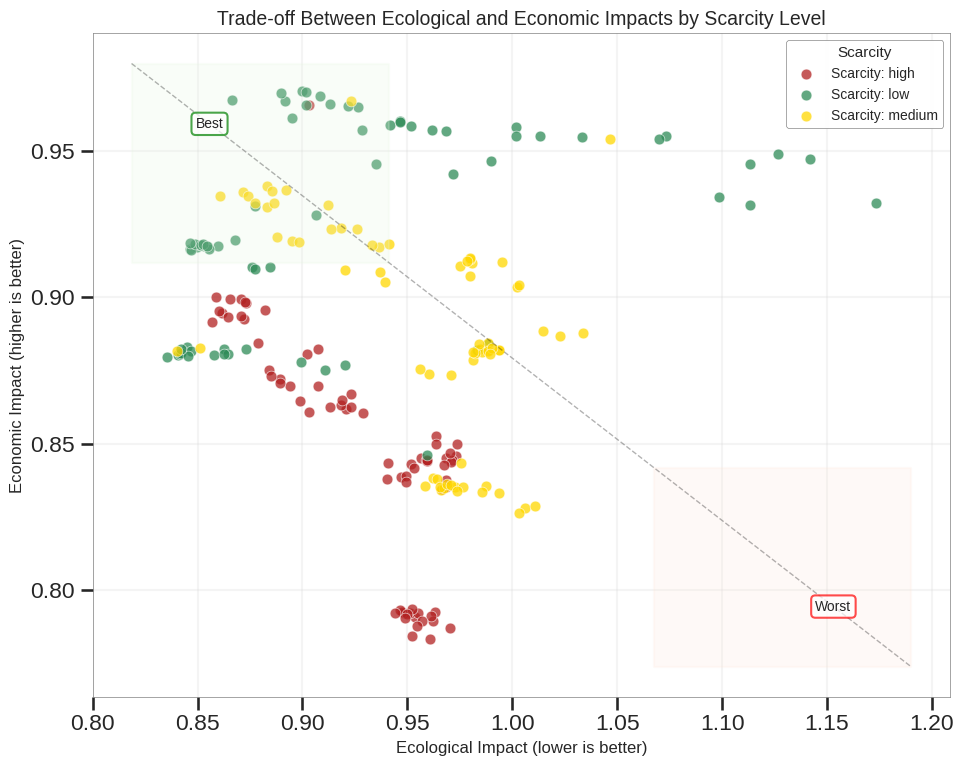

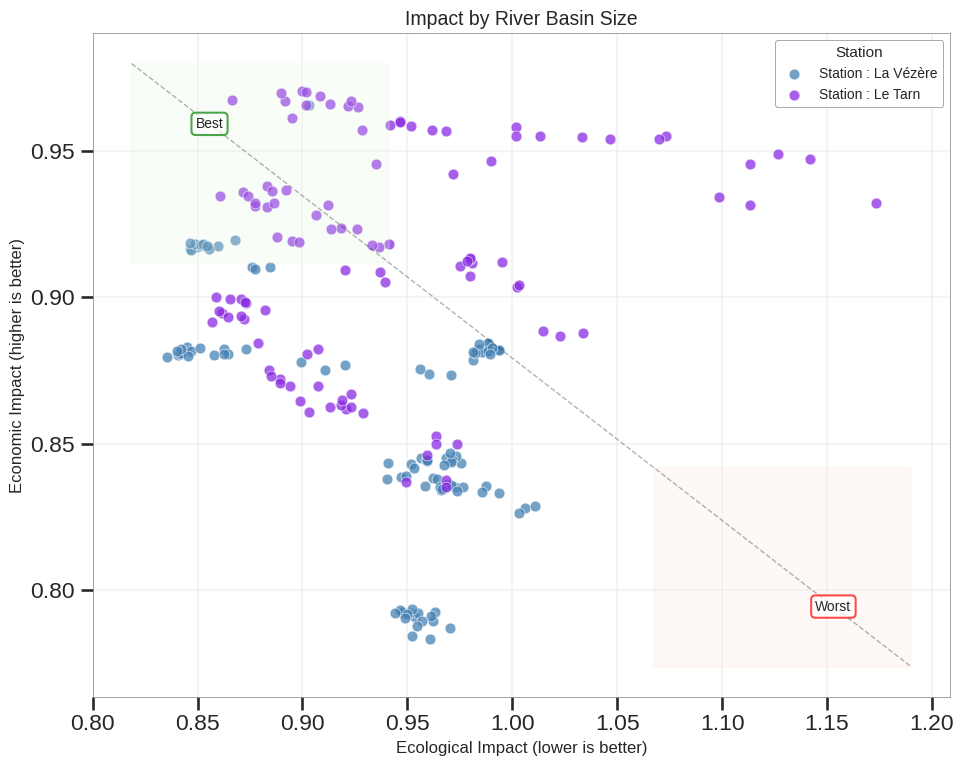

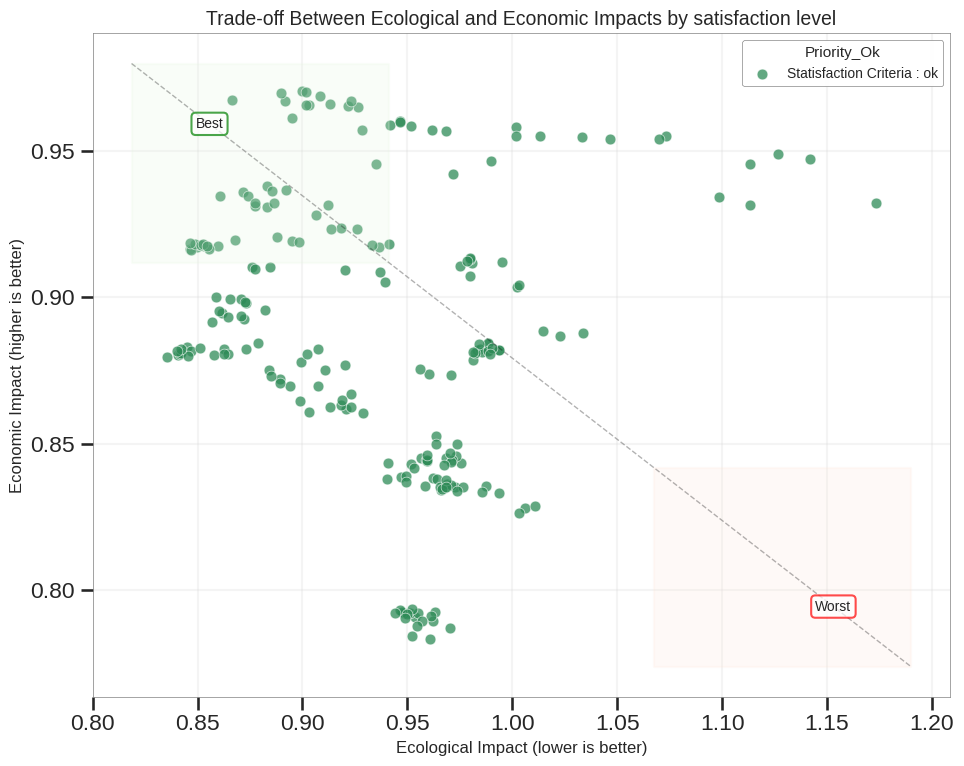

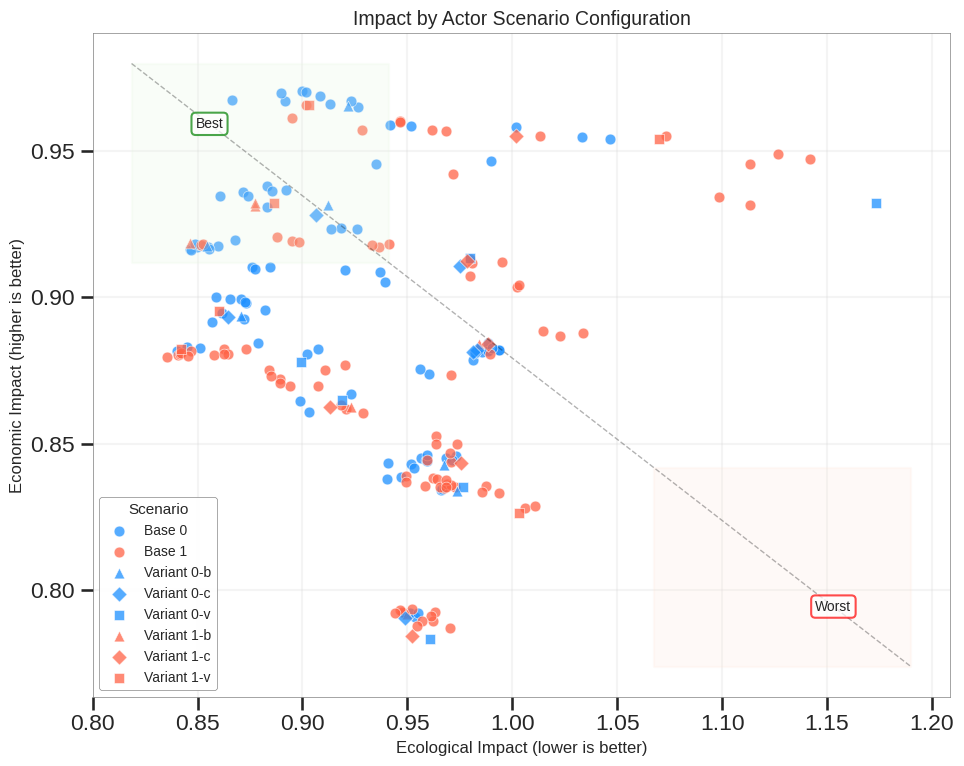

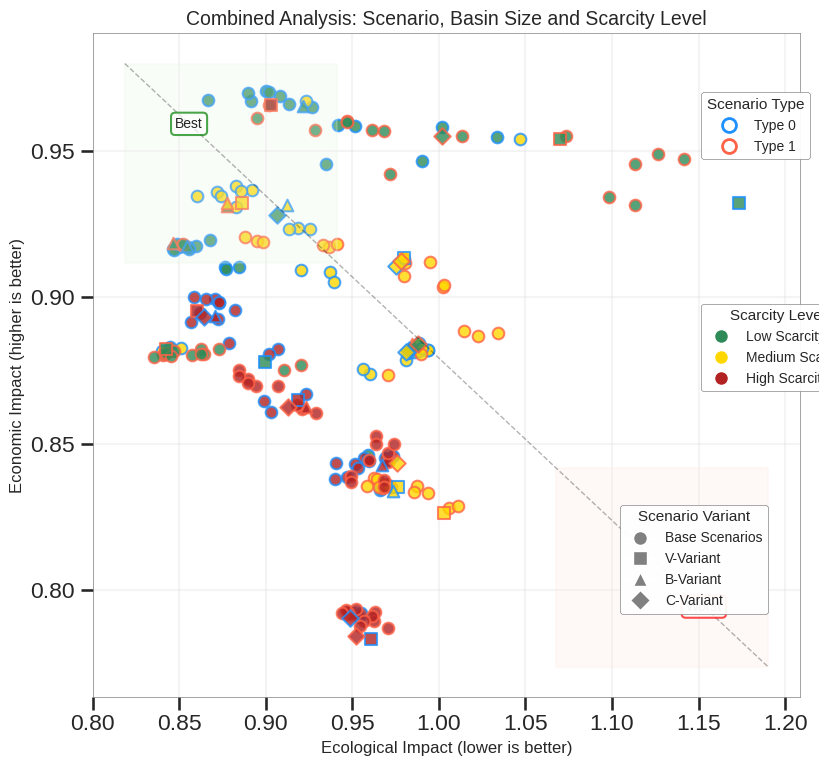

In [6]:
pma.analyze_scenario_impacts(results_df, is_scalled = True)

## Analyzing Forecast Bias & Uncertainty & Scarcity levels

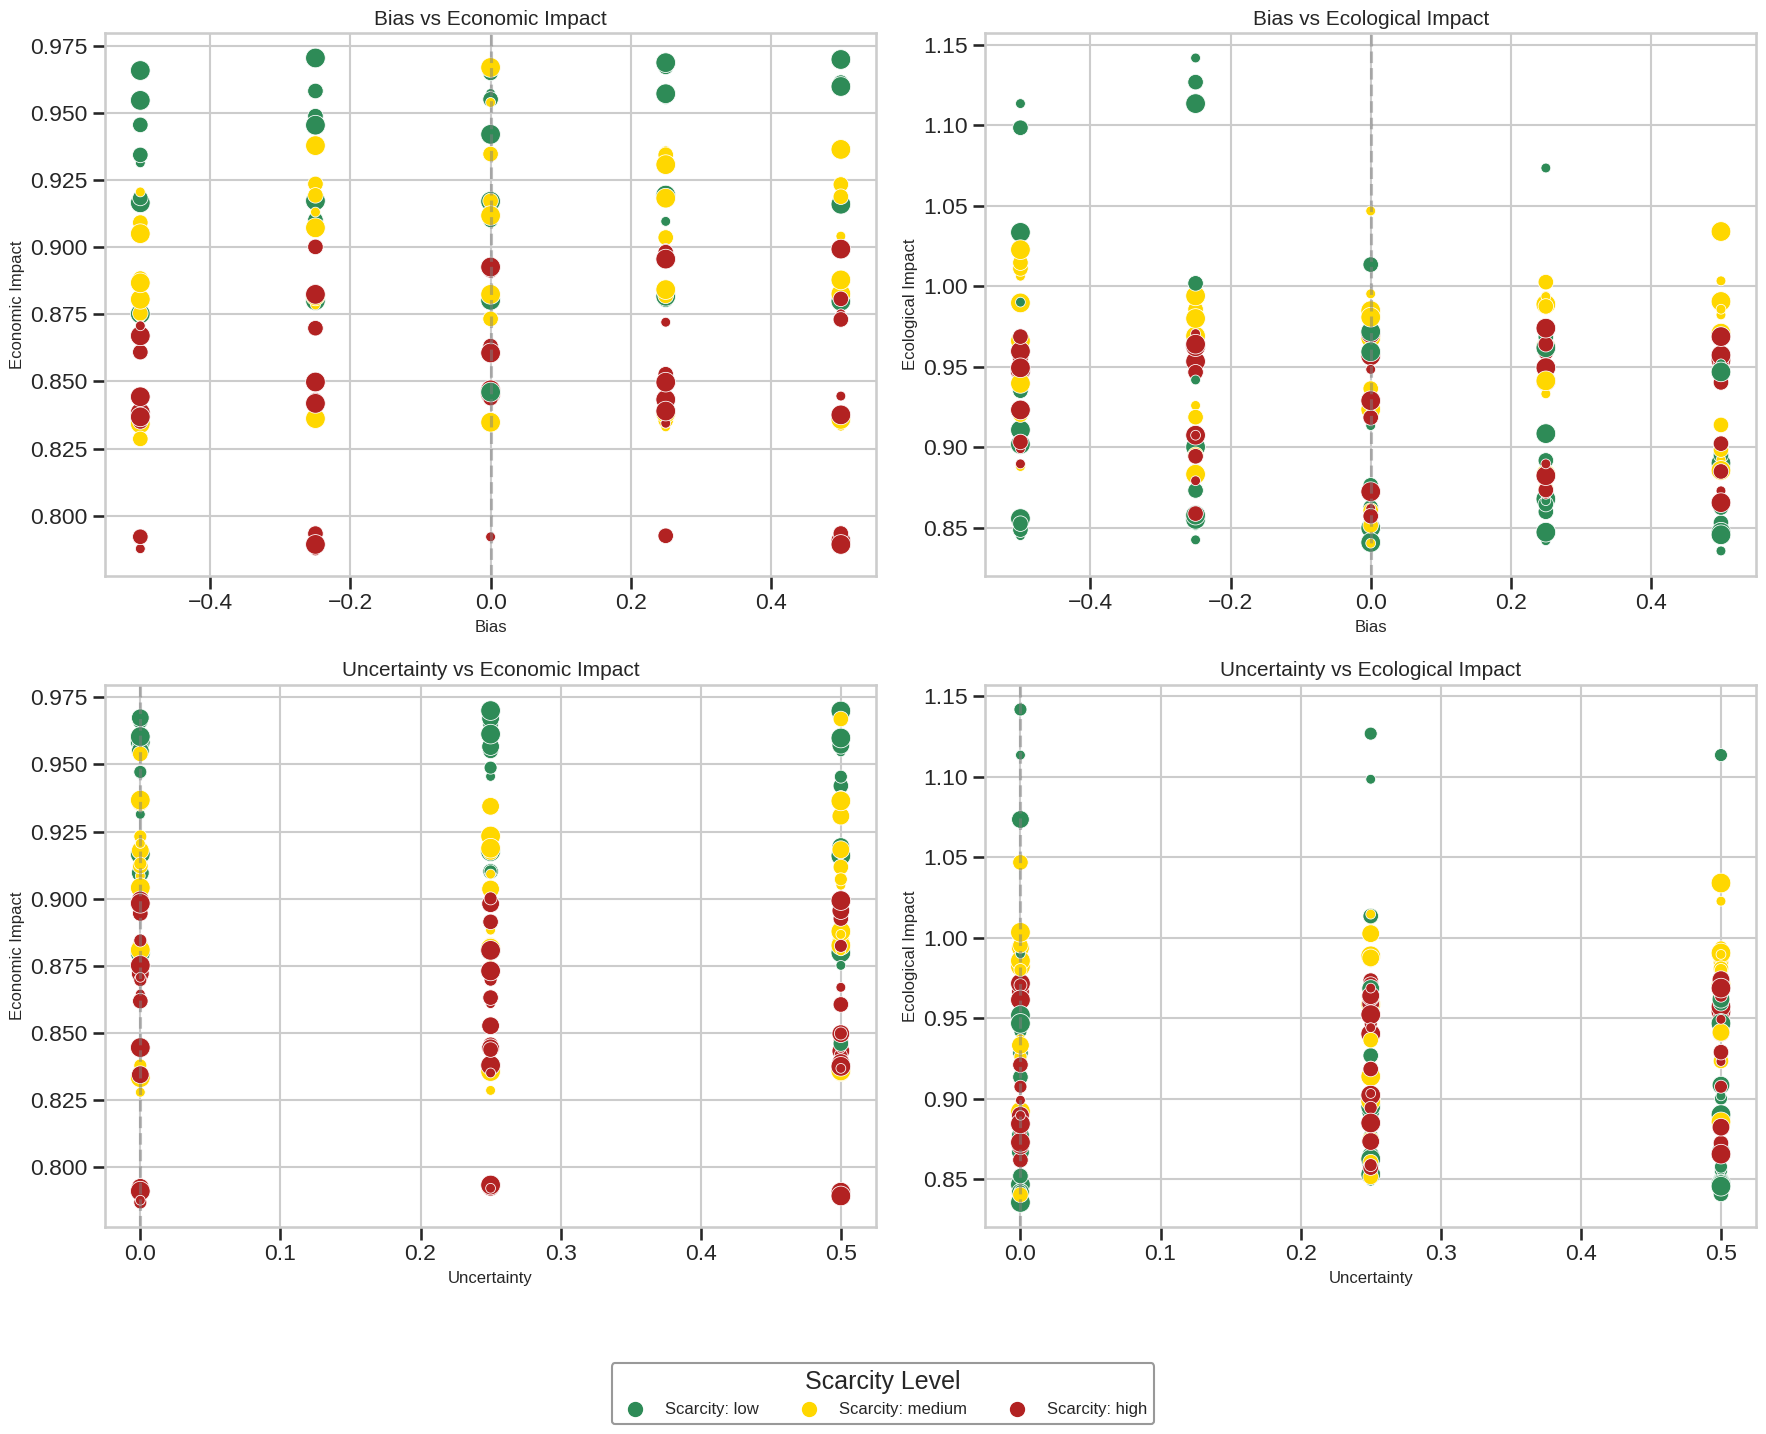

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:351: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:351: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




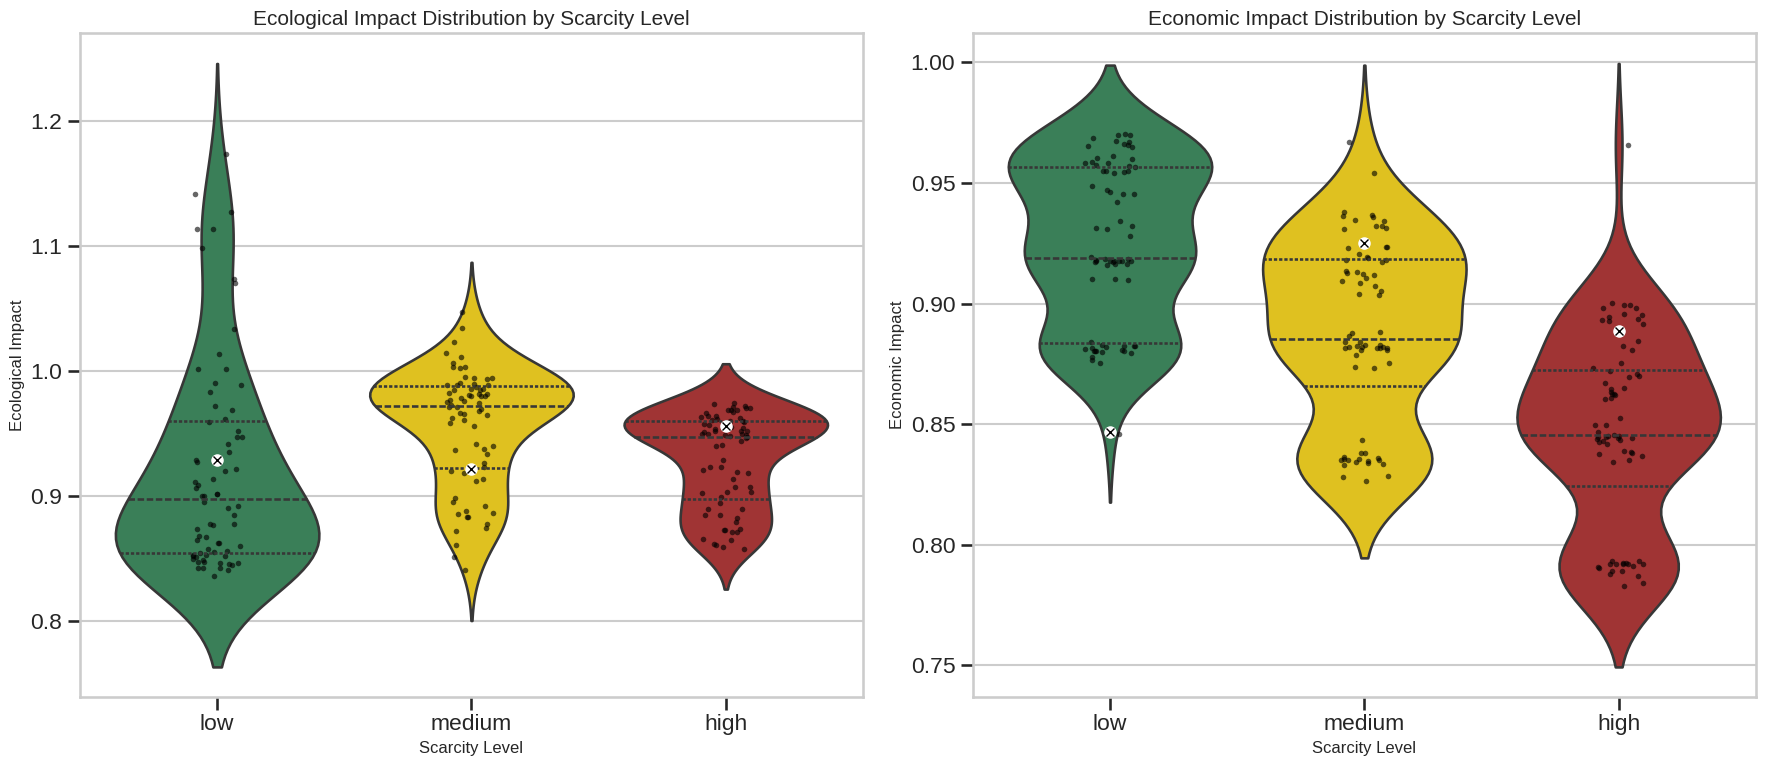

In [7]:
pma.analyze_forecast_effects(results_df, is_scalled = True)

## Correlation Analysis


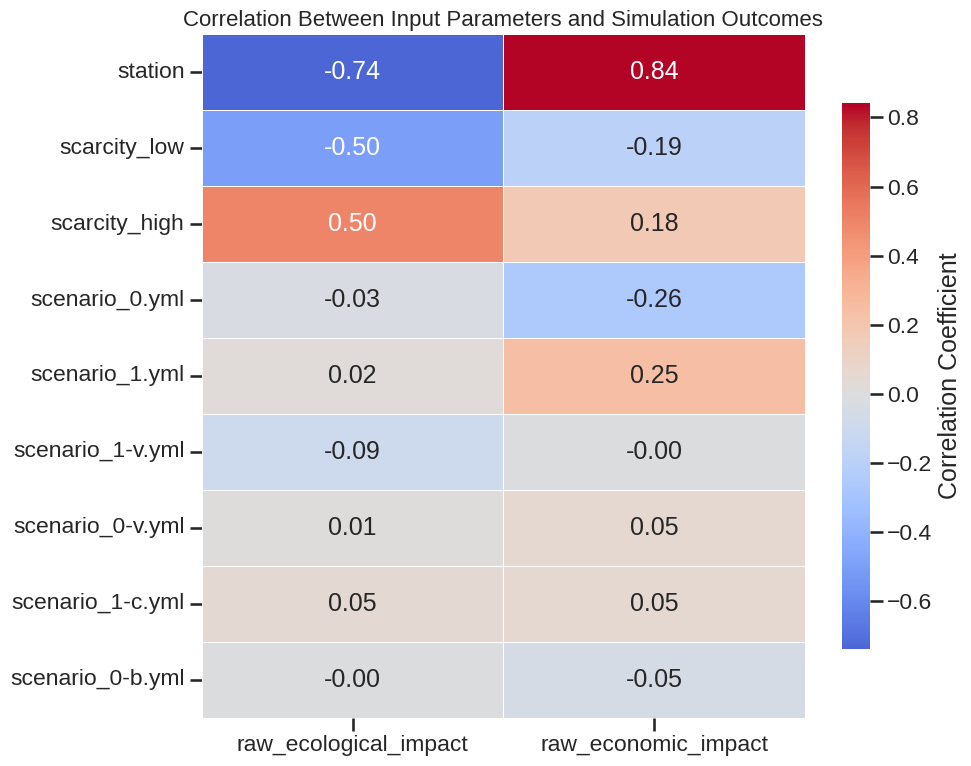


Top impacts on raw_ecological_impact:

Top 5 positive correlations:
  scarcity_high: 0.500
  scenario_1-c.yml: 0.049
  scenario_0-c.yml: 0.044
  uncertainty: 0.024
  scenario_1.yml: 0.021

Top 5 negative correlations:
  bias: -0.014
  scenario_0.yml: -0.030
  scenario_1-v.yml: -0.091
  scarcity_low: -0.500
  station: -0.739

Top impacts on raw_economic_impact:

Top 5 positive correlations:
  station: 0.843
  scenario_1.yml: 0.246
  scarcity_high: 0.178
  scenario_0-v.yml: 0.053
  scenario_1-c.yml: 0.053

Top 5 negative correlations:
  scenario_0-c.yml: -0.007
  uncertainty: -0.026
  scenario_0-b.yml: -0.052
  scarcity_low: -0.190
  scenario_0.yml: -0.261


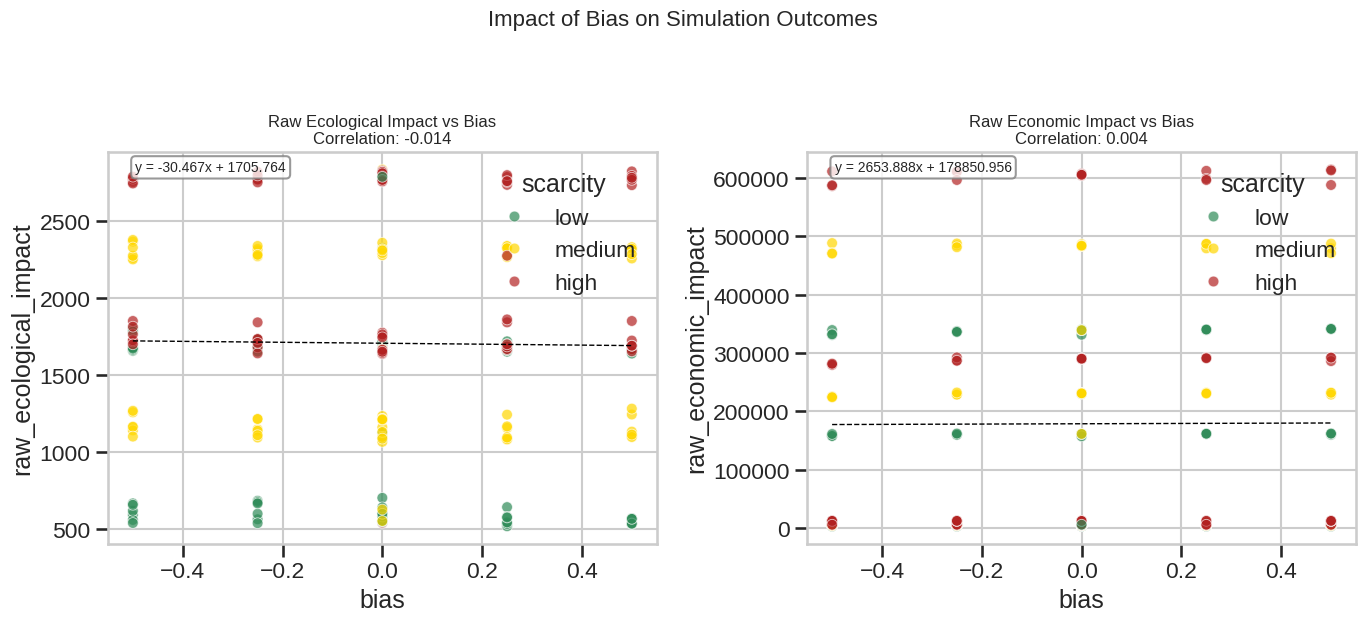

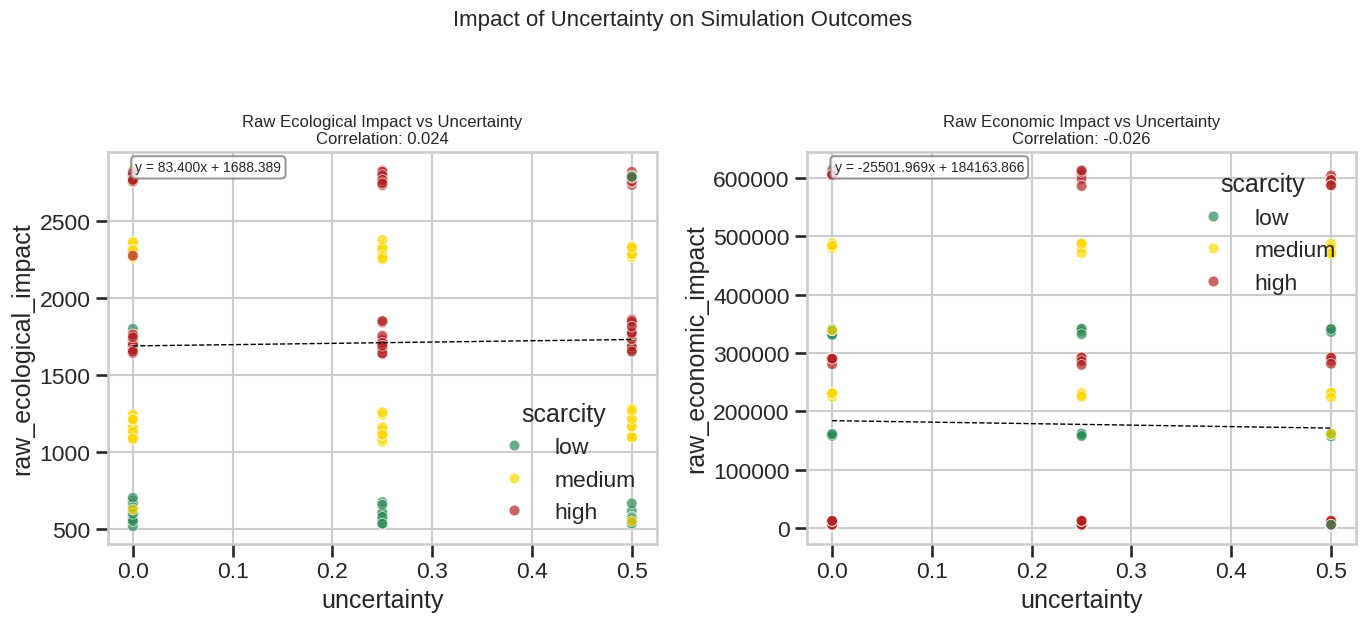

<Figure size 1200x1000 with 0 Axes>

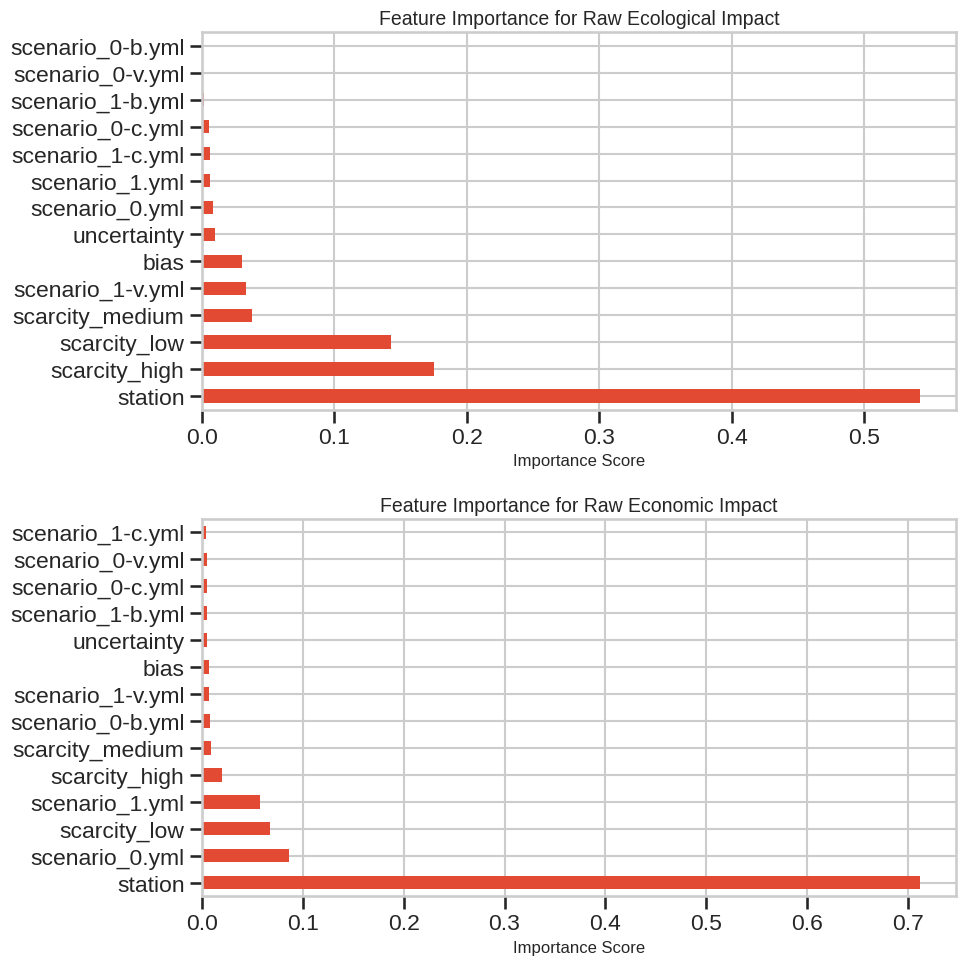

In [8]:
pma.correlation_analysis(results_df)

## Cooperation Analysis
Analyzing cooperation patterns across scenarios and their impact on ecological and economic outcomes.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:991: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




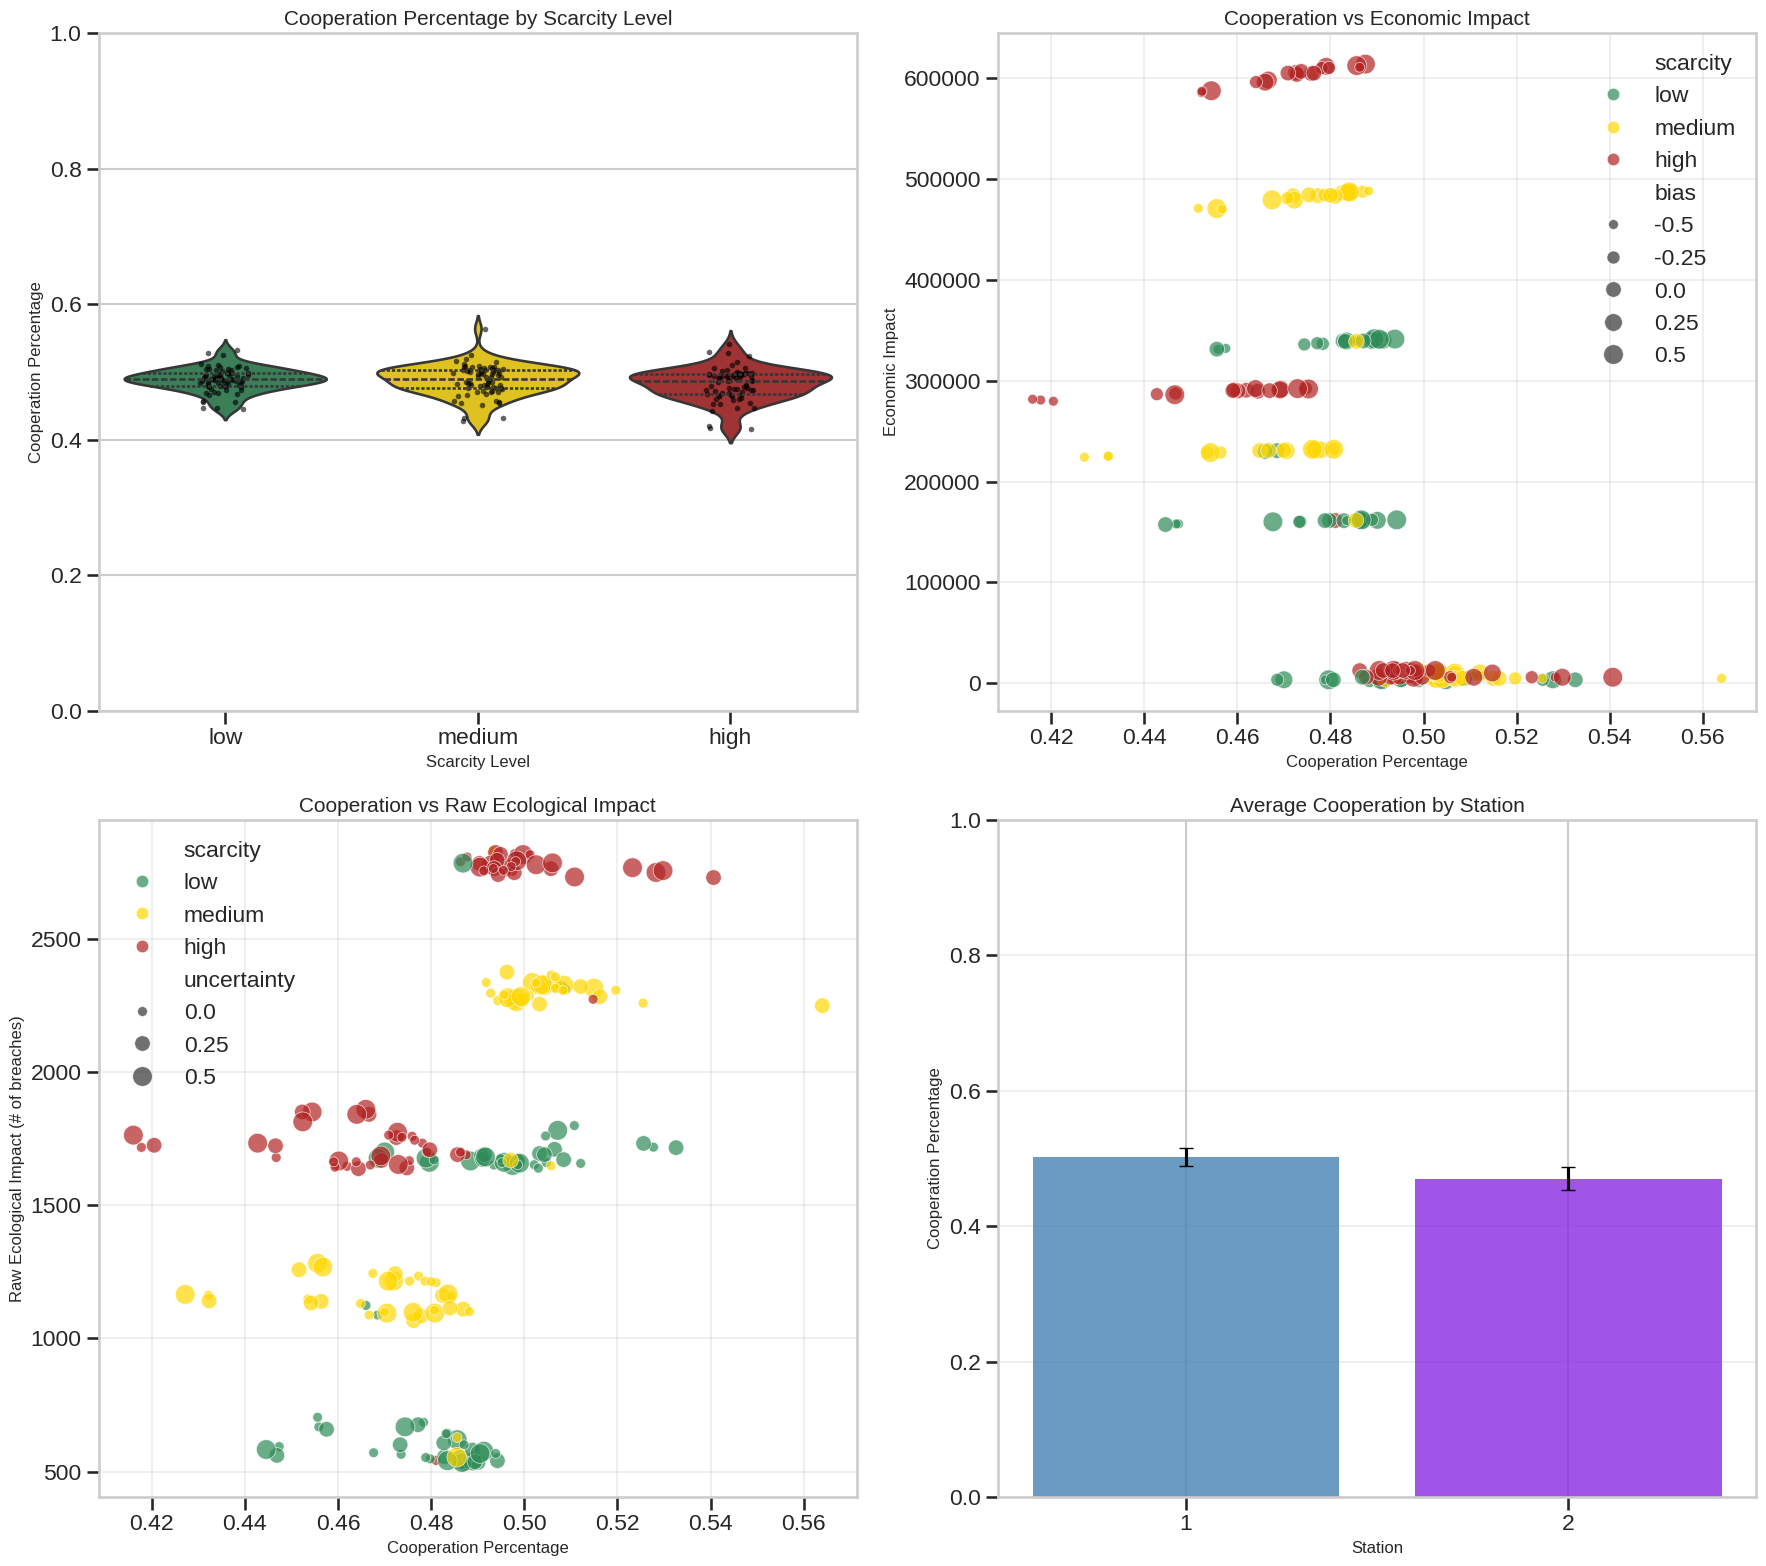

In [9]:
pma.analyze_cooperation_patterns(results_df)

## Raw Impact vs Scaled Impact
Analyzing the raw (unscaled) ecological impact across different scenarios.

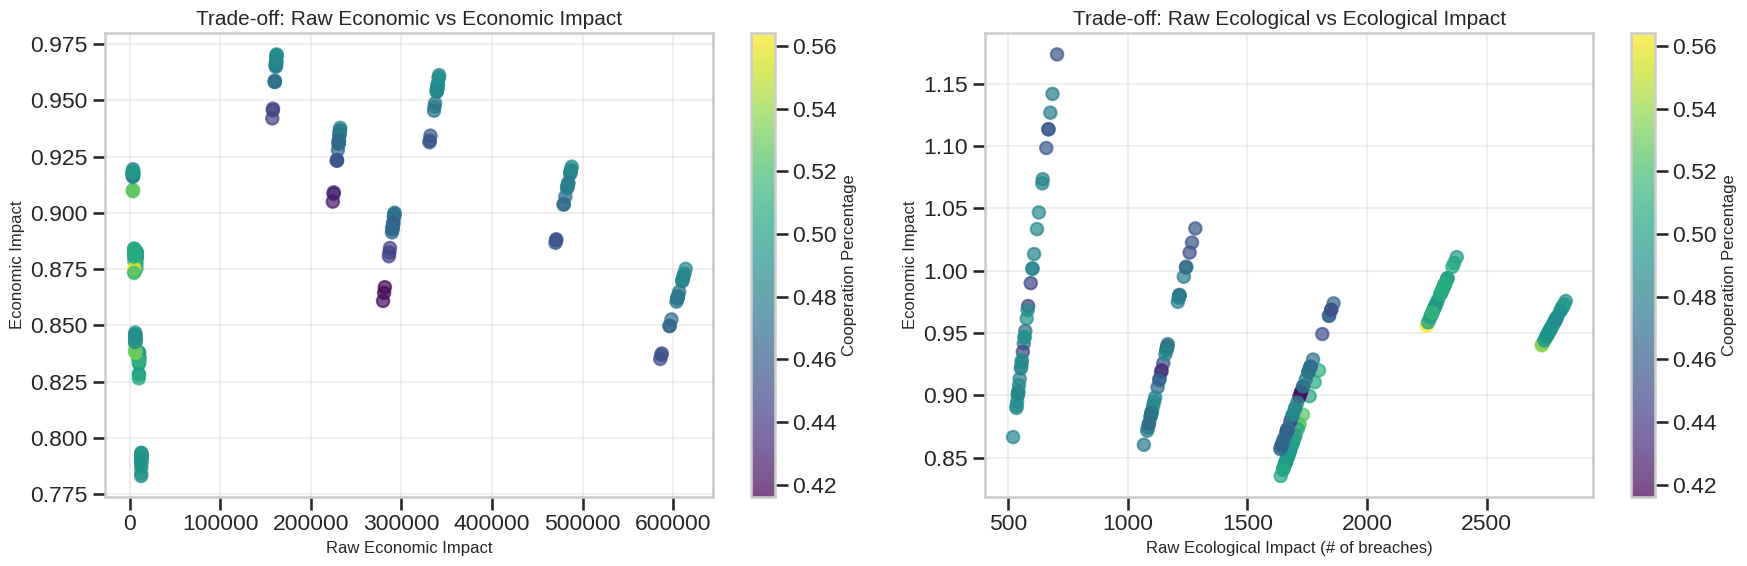

In [10]:
pma.analyze_raw_impact(results_df)

## Cooperation by Forecast Parameters
Analyzing how forecast bias and uncertainty affect cooperation levels.


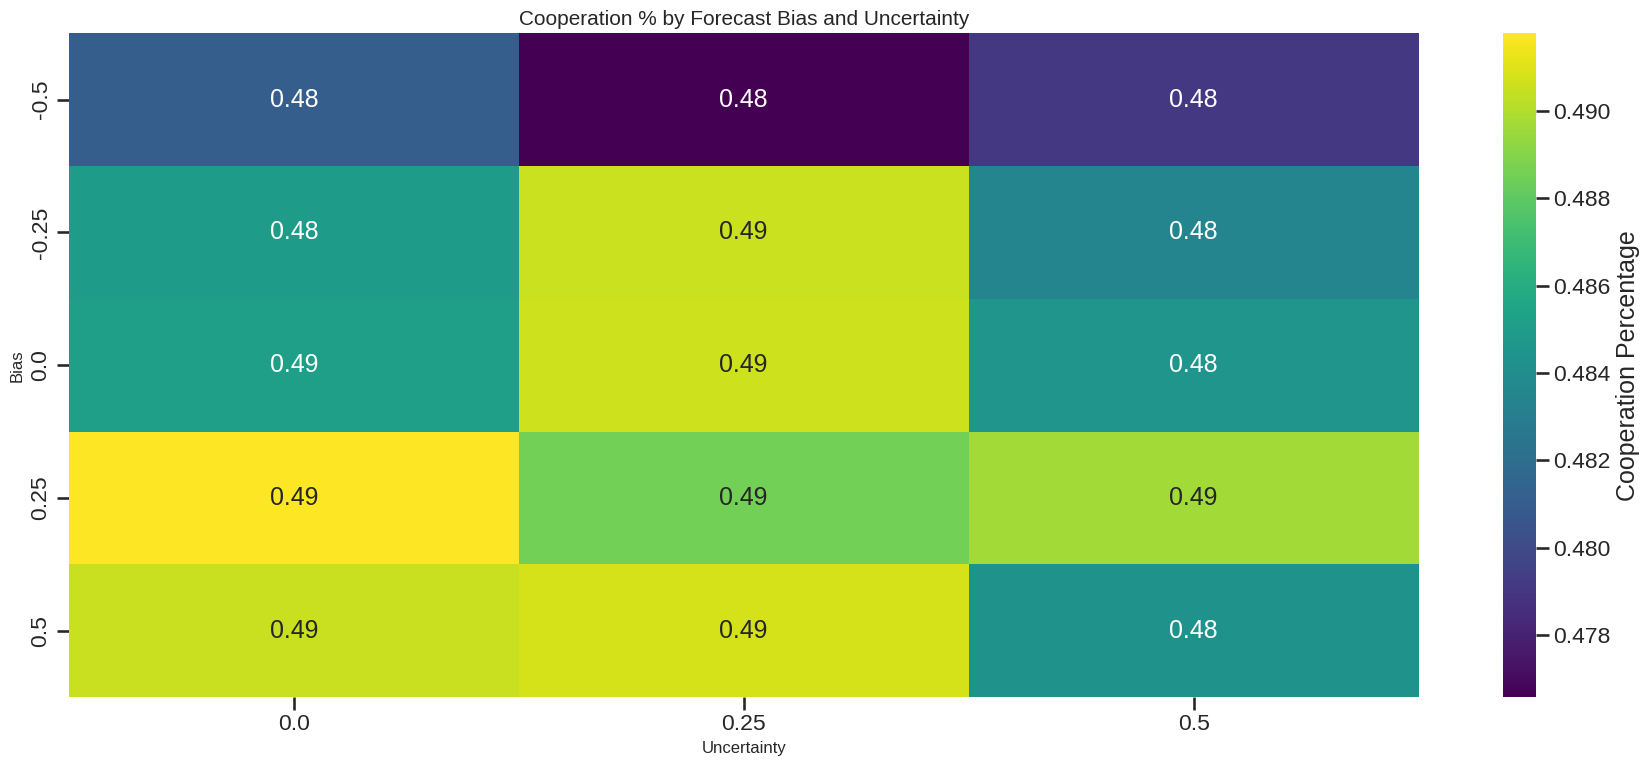

In [11]:
pma.analyze_cooperation_by_forecast_params(results_df)

## Comprehensive Analysis
Performing a comprehensive analysis of all metrics and their relationships.


In [12]:
results_df.priority_ok.mean()

1.0

=== Summary Statistics ===

Overall Metrics:
Average Cooperation: 0.49
Average Raw Ecological Impact: 1705.8 breaches
Average Scaled Ecological Impact: 0.935
Average Economic Impact: 0.887

Correlation Matrix:
                        cooperation_percentage  raw_ecological_impact  \
cooperation_percentage                    1.00                   0.46   
raw_ecological_impact                     0.46                   1.00   
ecological_impact                        -0.00                   0.05   
economic_impact                          -0.29                  -0.91   
raw_economic_impact                      -0.58                  -0.50   
bias                                      0.14                  -0.01   
uncertainty                              -0.03                   0.02   

                        ecological_impact  economic_impact  \
cooperation_percentage              -0.00            -0.29   
raw_ecological_impact                0.05            -0.91   
ecological_impact  

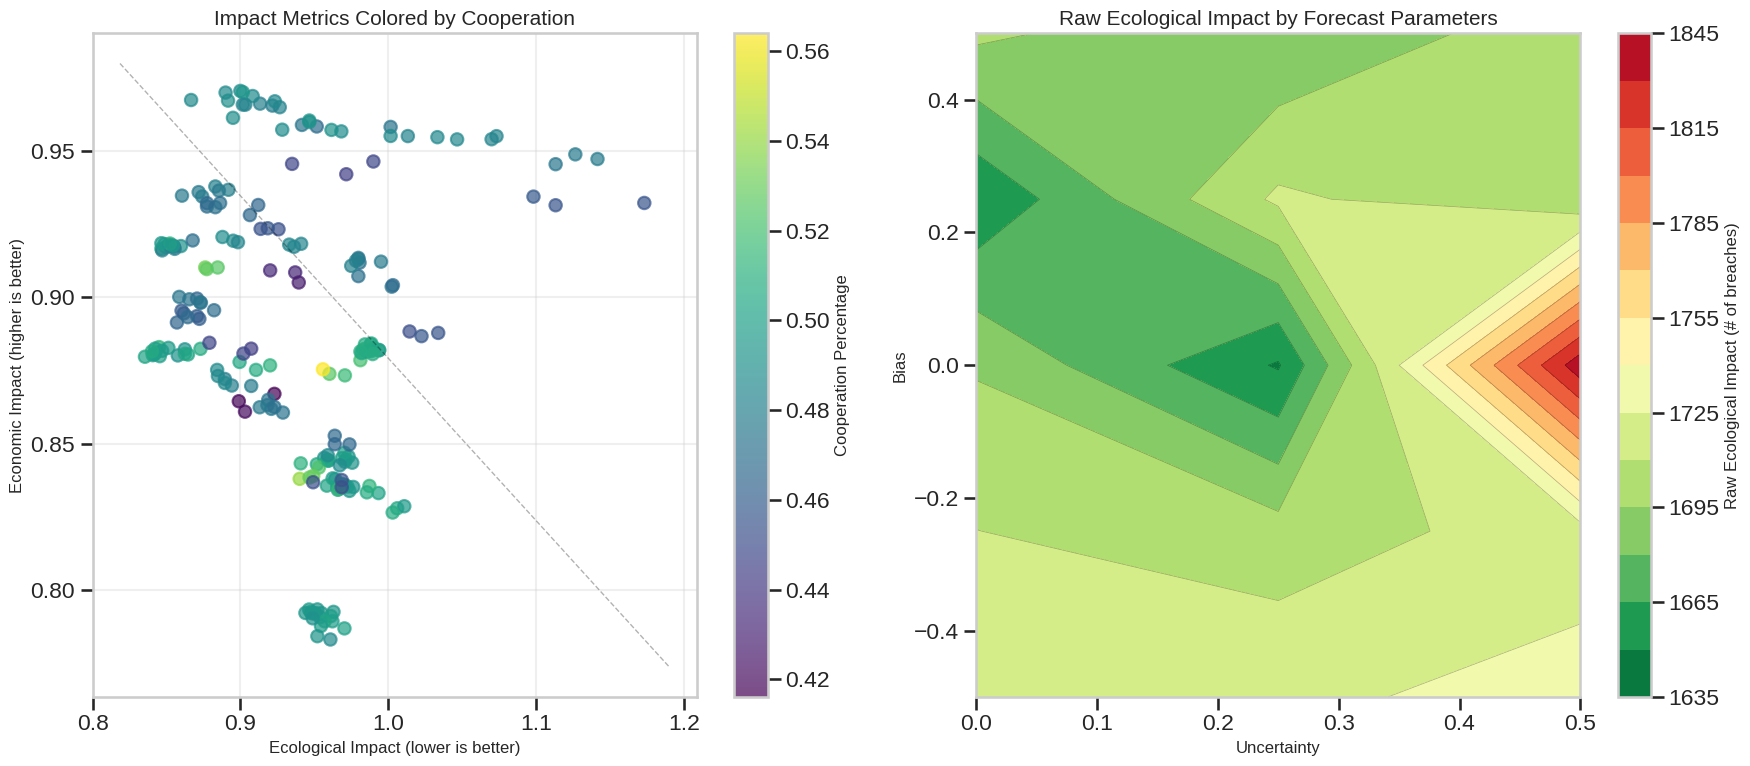

In [13]:
pma.comprehensive_analysis(results_df, is_scalled = True)

## Conclusion
This notebook has demonstrated how to analyze water allocation policies across multiple scenarios,
focusing on the balance between ecological and economic impacts. To participate in the hackathon:

1. Design your own adaptive policy by modifying the `custom_incentive_policy` and `custom_quota` functions
2. Test your policy across multiple scenarios using the tools provided
3. Optimize your policy to balance ecological integrity and economic benefits

Good luck!